# **NOAA Mauna Loa Atmospheric CO₂ Time Series Analysis**

This analysis examines the **monthly mean atmospheric carbon dioxide CO₂ concentrations** recorded at the **National Oceanic and Atmospheric Administration (NOAA) Mauna Loa Observatory, Hawaii**, expressed as **mole fraction in parts per million (ppm)**. Mole fraction in parts per million means the proportion of CO₂ molecules in the air, expressed per one million molecules. 
- `For example:` **400 ppm CO₂** means approximately **400 out of every 1,000,000 air molecules are CO₂**. 

The dataset provides monthly observations beginning in **1958**. The `average` variable represents the observed monthly mean CO₂ concentration and will serve as the principal series for analysis.

The primary objective is to investigate the **long-term trend**, **seasonal behavior**, and **time-series properties** of atmospheric CO₂ concentrations. The analysis will first examine the raw CO₂ series before proceeding to **stationarity testing, differencing, seasonal adjustment, and time-series modeling**. After selecting the best-performing model, a **multi-month future forecast** will be generated together with **confidence intervals**. Model performance will then be evaluated using a **chronological holdout set**, comparing the forecasts against the actual observed CO₂ concentrations.

The overall aim is to demonstrate the **full workflow of a time-series analysis**, from exploratory analysis and data preparation through model selection & validation, forecasting, and out-of-sample evaluation.

## **1. Loading and Preparing the CO₂ Data**
The dataset is loaded into a `pandas DataFrame`, and a proper monthly date index is created from the `year` and `month` columns. The data is then converted to a **monthly time-series frequency** (`MS`), indicating that observations occur at the start of each month.

In [1]:
import pandas as pd

df = pd.read_csv("../data/co2_mm_mlo.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1958-03-01  1958      3     1958.2027   315.71          314.44     -1 -9.99   
1958-04-01  1958      4     1958.2877   317.45          315.16     -1 -9.99   
1958-05-01  1958      5     1958.3699   317.51          314.69     -1 -9.99   
1958-06-01  1958      6     1958.4548   317.27          315.15     -1 -9.99   
1958-07-01  1958      7     1958.5370   315.87          315.20     -1 -9.99   

             unc  
date              
1958-03-01 -0.99  
1958-04-01 -0.99  
1958-05-01 -0.99  
1958-06-01 -0.99  
1958-07-01 -0.99  


### **1.1 Chronological Train-Holdout Split**
Because this is a **time-series dataset**, the observations must remain in chronological order. Randomly splitting the data could introduce **data leakage**, as information from the future could enter the training set. Therefore, the last 24 months are reserved as a **holdout set** for evaluating the model's 24-month-ahead forecasts.

In [2]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1958-03-01 00:00:00 to 2024-07-01 00:00:00
Number of observations: 797

Holdout data:
2024-08-01 00:00:00 to 2026-07-01 00:00:00
Number of observations: 24


## **2. Raw Series: Visual Inspection**
The raw monthly CO₂ series is plotted using the `average` concentration to identify its main time-series characteristics.

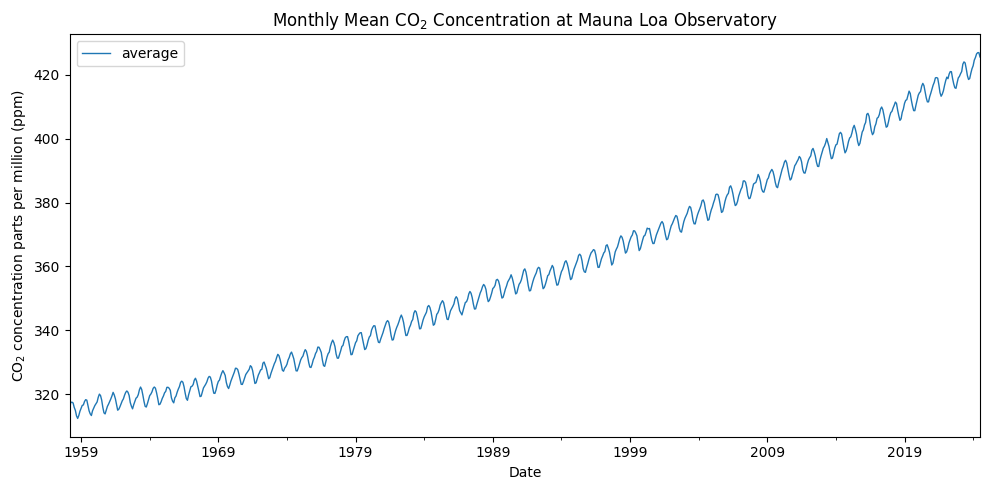

In [16]:
# Plot the raw series
import matplotlib.pyplot as plt

train.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly Mean CO$_2$ Concentration at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO$_2$ concentration parts per million (ppm)")
plt.tight_layout()
plt.show()

### Raw Series Plot Observation
- The plot shows two dominant features: a **strong long‑term upward trend** and a clear **recurring seasonal cycle**. 
- CO₂ concentrations increase from approximately **315 ppm in the late 1950s** to **over 420 ppm in recent years**, while exhibiting regular within-year fluctuations.
- The combination of trend and seasonality indicates that the mean and other statistical properties of the series change over time, suggesting that the raw series is **non-stationary**.
- These characteristics motivate the use of time-series methods capable of handling both **non-seasonal and seasonal dynamics**, such as seasonal decomposition and **SARIMA models**. 
- Formal stationarity checks will next be assessed using two complementary tests:
    - **Augmented Dickey–Fuller (ADF) Test**
        - `Null hypothesis:` the series contains a unit root and is non-stationary.
        - For the raw CO₂ series, we expect to **fail to reject the null hypothesis**.
    - **Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test**
        - `Null hypothesis:` the series is stationary around a deterministic trend.
        - For the raw CO₂ series, we expect to **reject the null hypothesis**.
- Using both tests provides stronger evidence about the stationarity properties of the series before differencing and model development

### **2.1 Raw Series: ACF and PACF**
Before carrying out the `ADF` and `KPSS` stationarity tests, we examine the **Autocorrelation Function (`ACF`)** and **Partial Autocorrelation Function (`PACF`)** of the raw CO₂ series. The ACF measures the correlation between the CO₂ series and its previous values at different lags, while the PACF measures the correlation at each lag after accounting for the effects of shorter lags. For monthly data, particular attention is given to **lag 12 and its multiples**, which can reveal the annual seasonal structure.

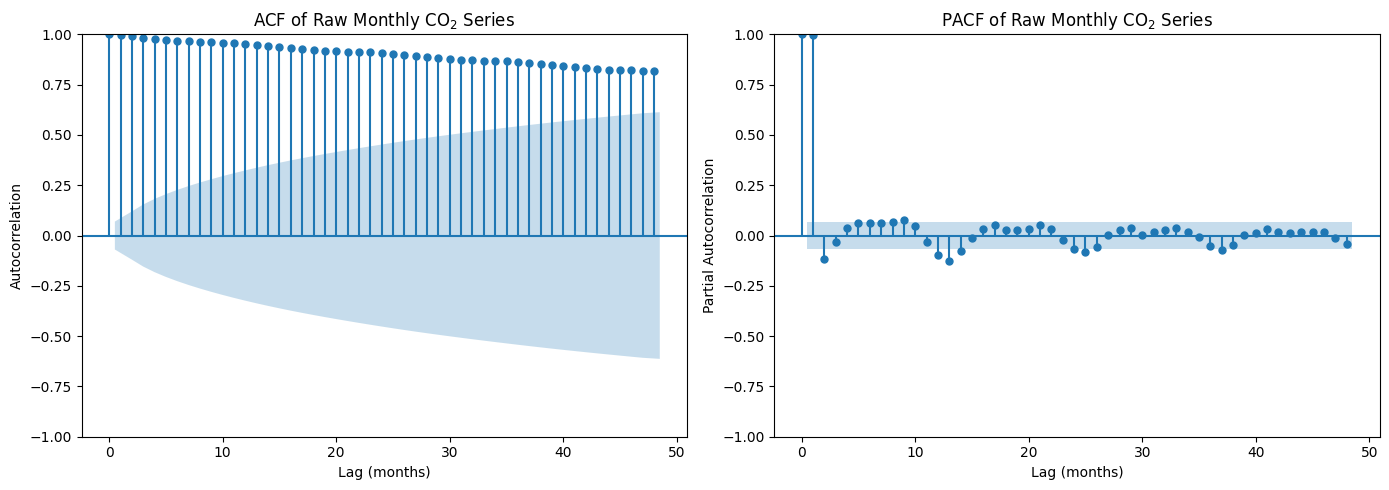

In [26]:
# Plot the ACF and PACF of the raw series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(train["average"].dropna(),lags=48,ax=axes[0],alpha=0.05)
axes[0].set_title("ACF of Raw Monthly CO$_2$ Series")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(train["average"].dropna(),lags=48,ax=axes[1],alpha=0.05,method="ywm")
axes[1].set_title("PACF of Raw Monthly CO$_2$ Series")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

#### Raw Series: ACF and PACF Observations
- The ACF remains strongly positive across many lags, indicating substantial persistence in the raw CO₂ series. The slow decay of the ACF is a characteristic of a **non-stationary series** with a **strong underlying trend**.
- Overall, the ACF and PACF provide additional visual evidence that the raw CO₂ series contains **strong temporal dependence**, **trend**, and **seasonality**.

### **2.2 Stationarity Tests: ADF and KPSS**
To formally assess the stationarity of the raw CO₂ series, both the `ADF`and `KPSS` tests are applied. The tests use complementary null hypotheses, providing stronger evidence when they lead to the same conclusion.

**ADF Test**
- `Null hypothesis` ($H_0$): The series has a unit root and is **non-stationary**.
- `Alternative hypothesis` ($H_1$): The series is **stationary**.
- **Decision rule:** Reject $H_0$ when the **p-value < 0.05**.

**KPSS Test**
- `Null hypothesis` ($H_0$): The series is **stationary**.
- `Alternative hypothesis` ($H_1$): The series is **non-stationary**
- **Decision rule:** Reject $H_0$ when the **p-value < 0.05**.

A significance level of **5\% ($\alpha = 0.05$)** is used throughout the analysis.

In [5]:
# ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(train["average"])

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(train["average"], regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 6.2373
p-value       : 1.0000
Lags Used     : 21
Observations  : 775

Critical Values:
   1%: -3.4388
   5%: -2.8653
   10%: -2.5688


KPSS Test
----------------
KPSS Statistic : 4.2289
p-value        : 0.0100
Lags Used      : 18

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2408/4057016753.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(train["average"], regression='c', nlags='auto')


#### Raw Series: Stationarity Test Results
##### 1. ADF Test
  - Test statistic: `ADF = 6.2373`
  - p‑value: `p = 1.0000`
  - Critical values:
    - 1%: `-3.4388` 
    - 5%: `-2.8653`
    - 10%: `-2.5688`

Since the p-value is much greater than 0.05 and the test statistic is far above all critical value, we **fail to reject the null hypothesis**.

**Interpretation:** The ADF test provides strong evidence that the raw CO₂ series is **non-stationary**.

##### 2. KPSS Test
- Test statistic: `KPSS = 4.2289`  
- p‑value: `p = 0.0100` (actual p‑value even smaller; outside lookup table range)  
- Critical values:  
  - 1%: `0.7390`  
  - 2.5%: `0.5740`  
  - 5%: `0.4630`  
  - 10%: `0.3470`

Since the KPSS statistic is substantially greater than all critical values and the p-value is below 0.05, we **reject the null hypothesis of stationarity**.

**Interpretation:** The KPSS test also indicates that the raw CO₂ series is **non-stationary**.

**Note:** The `InterpolationWarning` indicates that the KPSS statistic is outside the range covered by the p-value lookup table. Therefore, `0.0100` should be interpreted as the smallest reported table value; the **actual p-value is smaller than 0.0100**.

---

#### Combined Interpretation

Both tests independently indicate that the raw CO₂ series is **non-stationary**. This is consistent with the strong upward trend and recurring seasonal structure observed in the previous plots.

The series therefore requires further transformation before fitting models that assume stationarity. The next stage is to investigate **differencing and seasonal differencing**, followed by re-examination of the ACF, PACF, ADF, and KPSS statistics.

## **3. Differencing the CO₂ Raw Series**
To obtain a stationary series suitable for time-series modelling, differencing is considered. Two common approaches are **absolute (regular) differencing** and **log differencing**. Regular differencing measures the absolute change in CO₂ concentration;

$$\Delta CO_{2,t} = CO_{2,t} - CO_{2,t-1}$$

whereas log differencing measures the proportional change:
$$\Delta \log(CO_{2,t}) = \log(CO_{2,t}) - \log(CO_{2,t-1}) = \log\left(\frac {CO_{2,t}}{CO_{2,t-1}}\right)$$

Because the CO₂ series is measured in **ppm** and the focus here is on changes in concentration in physical units rather than percentage growth, **absolute differencing is used**. Log differencing would instead be appropriate when the primary interest is in relative or percentage changes.


### **3.1 Regular First Differencing**

The first step is to apply **regular first differencing** with a **lag of 1** to the raw monthly CO₂ concentration series. Regular differencing removes changes in the series associated with the long-term trend and transforms the analysis from CO₂ concentration levels to **month-to-month changes in concentration**.

The resulting series is plotted below to assess visually whether the long-term upward trend has been removed and to determine whether any systematic pattern remains.


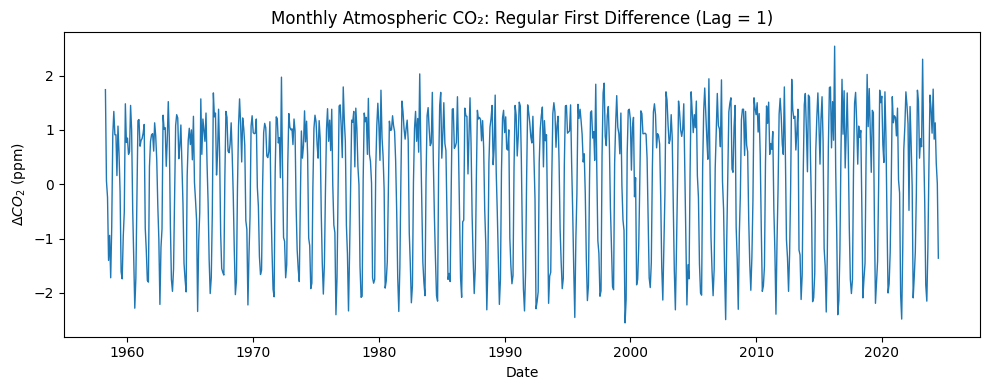

In [16]:
# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1)
plt.title("Monthly Atmospheric CO₂: Regular First Difference (Lag = 1)")
plt.xlabel("Date")
plt.ylabel(r"$\Delta CO_2$ (ppm)")
plt.tight_layout()
plt.show()

#### Regular First Differencing Observations

Regular first differencing substantially removes the long-term upward trend evident in the raw CO₂ series. The transformed series now fluctuates around a relatively stable mean rather than exhibiting a persistent increase over time.

However, a pronounced **seasonal oscillation remains visible**. The repeated pattern in the month-to-month changes indicates that regular differencing has removed much of the non-seasonal trend but has not eliminated the annual seasonal component. This remaining seasonality is investigated using the ACF and PACF below.


### **3.2 ACF and PACF of the Regularly Differenced CO₂ Series**

To further investigate the dependence structure remaining after regular differencing, the **ACF** and **PACF** are examined. For monthly data, particular attention is given to lags **12, 24, 36, and 48**, which correspond to one, two, three, and four-year intervals. Pronounced correlations at these lags would provide evidence of an annual seasonal cycle.


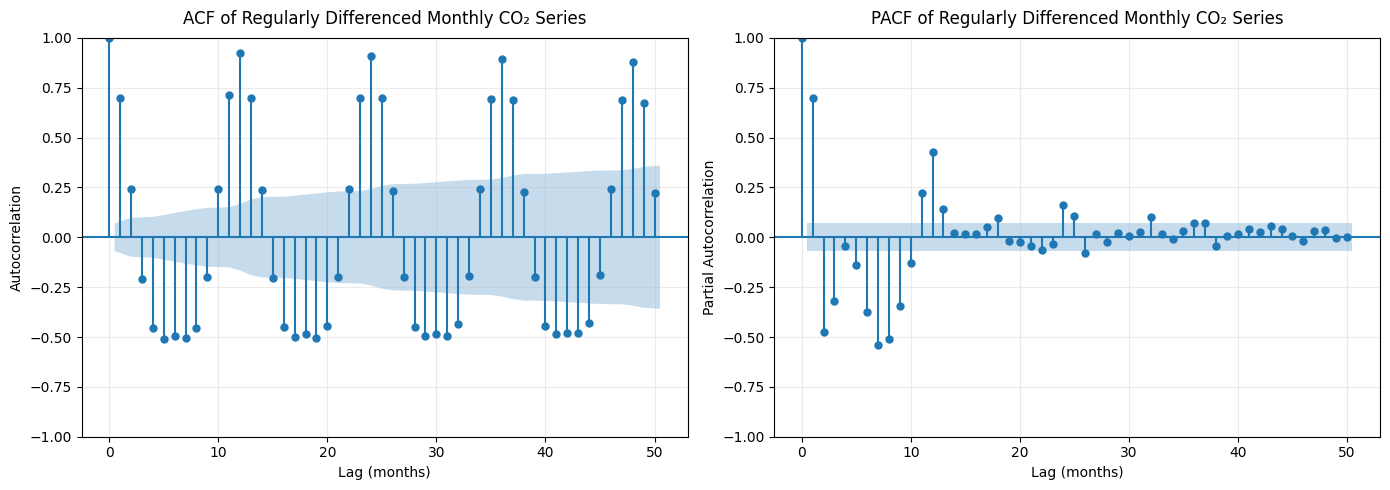

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Regularly differenced series
diff_regular = train["average"].diff(1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ACF ---
plot_acf(diff_regular,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title(
    "ACF of Regularly Differenced Monthly CO₂ Series",
    fontsize=12,
    pad=10
)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_regular,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title(
    "PACF of Regularly Differenced Monthly CO₂ Series",
    fontsize=12,
    pad=10
)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


#### ACF and PACF: Seasonal Dependence

The ACF of the regularly differenced series exhibits pronounced positive autocorrelation at approximately **12-month intervals**, with additional peaks at lags 24, 36, and 48. This repeating structure is characteristic of a strong **annual seasonal cycle** in atmospheric CO₂ concentrations.

The PACF also shows significant dependence at short and seasonal lags, confirming that temporal dependence remains after regular differencing. Thus, although regular differencing has effectively addressed the long-term trend, it has **not removed the annual seasonal structure**. The strong seasonal peaks at lags 12, 24, 36, and 48 therefore indicate that a **seasonal differencing component with a period of 12 months** is appropriate to investigate further.


### **3.3 Monthly Distribution of the Regularly Differenced CO₂ Series**

The seasonal structure remaining after regular first differencing can be examined more directly by grouping the differenced CO₂ observations by calendar month. The boxplot below shows the distribution of month-to-month changes in atmospheric CO₂ concentration for each month of the year.

Because the series has been regularly differenced, positive values indicate that atmospheric CO₂ increased relative to the previous month, while negative values indicate a month-to-month decrease. When the distribution of the differences varies systematically across calendar months, this provides visual evidence of **seasonality in the rate of change of atmospheric CO₂**.


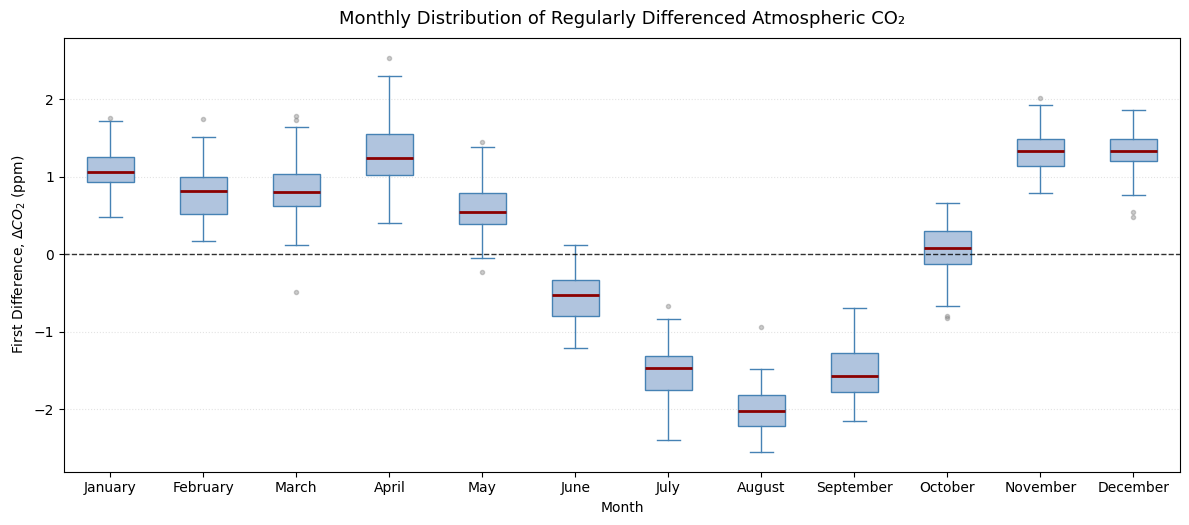

In [24]:
import calendar
# Prepare regularly differenced CO2 series
co2_diff = train[["diff_regular"]].dropna().copy()

# Extract calendar month
co2_diff["Month"] = co2_diff.index.month_name()

# Preserve chronological order
month_order = list(calendar.month_name[1:])
co2_diff["Month"] = pd.Categorical(co2_diff["Month"],
    categories=month_order,
    ordered=True
)

# Boxplot
fig, ax = plt.subplots(figsize=(12, 5.5))
co2_diff.boxplot(column="diff_regular",by="Month",ax=ax,grid=False,patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue",color="steelblue"),
    medianprops=dict(color="darkred",linewidth=2),
    whiskerprops=dict(color="steelblue"),
    capprops=dict(color="steelblue"),
    flierprops=dict(marker="o",markersize=3,markerfacecolor="gray",markeredgecolor="gray",alpha=0.4)
)

# Remove pandas automatic title
plt.suptitle("")
# Zero line: very important for interpreting increases vs decreases
ax.axhline(0,color="black",linestyle="--",linewidth=1,alpha=0.8)

ax.set_title("Monthly Distribution of Regularly Differenced Atmospheric CO₂",
    fontsize=13,pad=10)

ax.set_xlabel("Month")
ax.set_ylabel(r"First Difference, $\Delta CO_2$ (ppm)")

ax.grid(axis="y",linestyle=":",alpha=0.35)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Monthly Seasonal Pattern in CO₂ Changes
The boxplot reveals a clear seasonal structure in the **month-to-month changes** in atmospheric CO₂ concentration. The distributions of the first differences vary systematically across the calendar year rather than being centered around the same value for all months.

In particular, the summer months, especially **July, August, and September**, show substantially more negative first differences. A negative value means; $\Delta CO_{2,t} < 0,$ or equivalently, $CO_{2,t} < CO_{2,t-1}.$ Thus, the large negative values during these months indicate that atmospheric CO₂ concentration commonly **decreases from the preceding month** during this part of the year.

#### What Causes the Monthly Seasonal Pattern?

This seasonal behaviour pattern is physically consistent with the dominant influence of the terrestrial biosphere on atmospheric CO₂. The seasonal CO₂ cycle is particularly strong because a large proportion of the Earth's land area and vegetation is located in the **Northern Hemisphere**. During Northern Hemisphere spring and summer, increased photosynthetic activity removes CO₂ from the atmosphere, while during autumn and winter, reduced photosynthesis and continued respiration & decomposition return more CO₂ to the atmosphere. This produces a recurring annual oscillation in atmospheric CO₂ concentrations.

Conversely, during the Northern Hemisphere winter, photosynthetic CO₂ uptake is substantially reduced, while energy demand for heating generally increases. The associated combustion of fossil fuels for heating and electricity generation, together with continued transportation and other human activities, adds CO₂ to the atmosphere during a period when natural terrestrial uptake is relatively weak. The combination of these factors produces a recurring annual oscillation and upward trend in atmospheric CO₂ concentrations.

#### Why does the Southern Hemisphere not cancel the Northern Hemisphere cycle?

Although the Southern Hemisphere experiences its growing season while the Northern Hemisphere is in winter, its influence is considerably weaker. The key reason is the strong **asymmetry in land and vegetation distribution** between the two hemispheres. The Northern Hemisphere contains substantially more land and terrestrial vegetation, whereas the Southern Hemisphere is dominated by oceans.

Consequently, the seasonal uptake and release of CO₂ by Northern Hemisphere terrestrial ecosystems is much larger than the corresponding seasonal cycle in the Southern Hemisphere. The Southern Hemisphere therefore partially offsets the Northern Hemisphere signal, but not enough to cancel it. Therefore, the resulting global atmospheric CO₂ record retains a pronounced annual cycle dominated by the Northern Hemisphere biosphere.

Finally, the monthly boxplot provides a clear visual explanation for the seasonal peaks observed in the ACF: the month-to-month change in atmospheric CO₂ is itself strongly dependent on the **time of year**. This confirms that regular differencing has removed much of the long-term trend but has **not removed the annual seasonal component**, motivating the application of seasonal differencing with a period of \(s=12\).

### **3.4 Seasonal and Regular Differencing**

Since regular differencing removes the long-term trend but leaves a pronounced annual seasonal pattern, we next apply **seasonal differencing** with a period of $s=12$, together with the regular first difference.

The combined transformation is:
$$(1-B)(1-B^{12})CO_{2,t},$$

where $B$ is the backshift operator. Equivalently;
$$\Delta_1\Delta_{12}CO_{2,t}=CO_{2,t}-CO_{2,t-1}-CO_{2,t-12}+CO_{2,t-13}.$$

This transformation is intended to remove both the **long-term non-seasonal trend** and the **annual seasonal component** from the monthly CO₂ series.


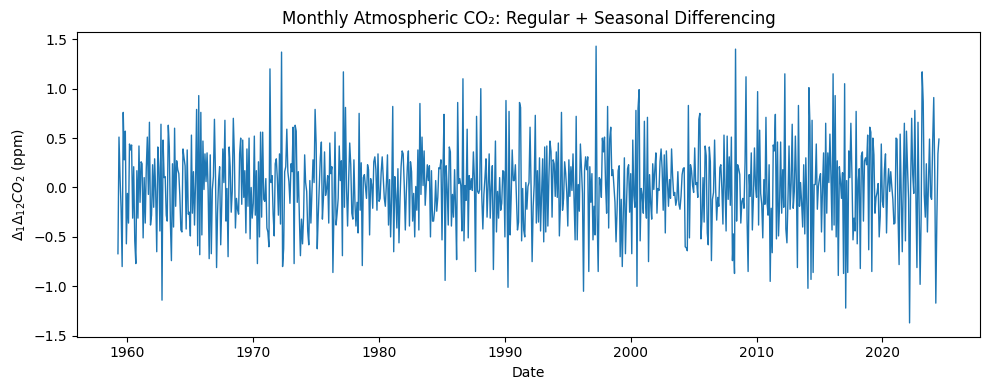

In [27]:
# --- Combined differencing: seasonal + regular ---
train["diff_both"] = train["average"].diff(12).diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_both"], linewidth=1)
plt.title("Monthly Atmospheric CO₂: Regular + Seasonal Differencing")
plt.xlabel("Date")
plt.ylabel(r"$\Delta_1\Delta_{12} CO_2$ (ppm)")
plt.tight_layout()
plt.show()

#### Combined Differencing: Observations
After applying both regular and seasonal differencing, the long-term upward trend is no longer apparent, and the pronounced annual oscillation observed in the regularly differenced series is substantially reduced.

The resulting series fluctuates around a relatively stable level, suggesting that the combined transformation has removed the major sources of non-stationarity associated with the trend and annual seasonality. The ACF and PACF of the transformed series are examined next to determine whether substantial autocorrelation remains.

### **3.5 ACF and PACF of the Seasonally and Regularly Differenced CO₂ Series**

The ACF and PACF are now examined for the series after applying both seasonal differencing (`s = 12`) and regular differencing (`lag = 1`). At this stage, the objective is to determine whether the dominant trend and seasonal dependence have been removed and to identify any remaining short-term or seasonal autocorrelation that may be relevant for subsequent **SARIMA model** specification.

- The **ACF** helps in identifying the **MA(q)** component by showing how many significant autocorrelation spikes remain after differencing.
- The **PACF** helps identify the **AR(p)** component by showing how many partial autocorrelation spikes remain.
- Seasonal spikes at lag 12 (and multiples) often indicate the need for seasonal AR or MA terms in a SARIMA model.
- Together, the ACF and PACF plots guide the selection of `(p, d, q)` and `(P, D, Q)` for SARIMA.

We will use these plots to propose candidate SARIMA models


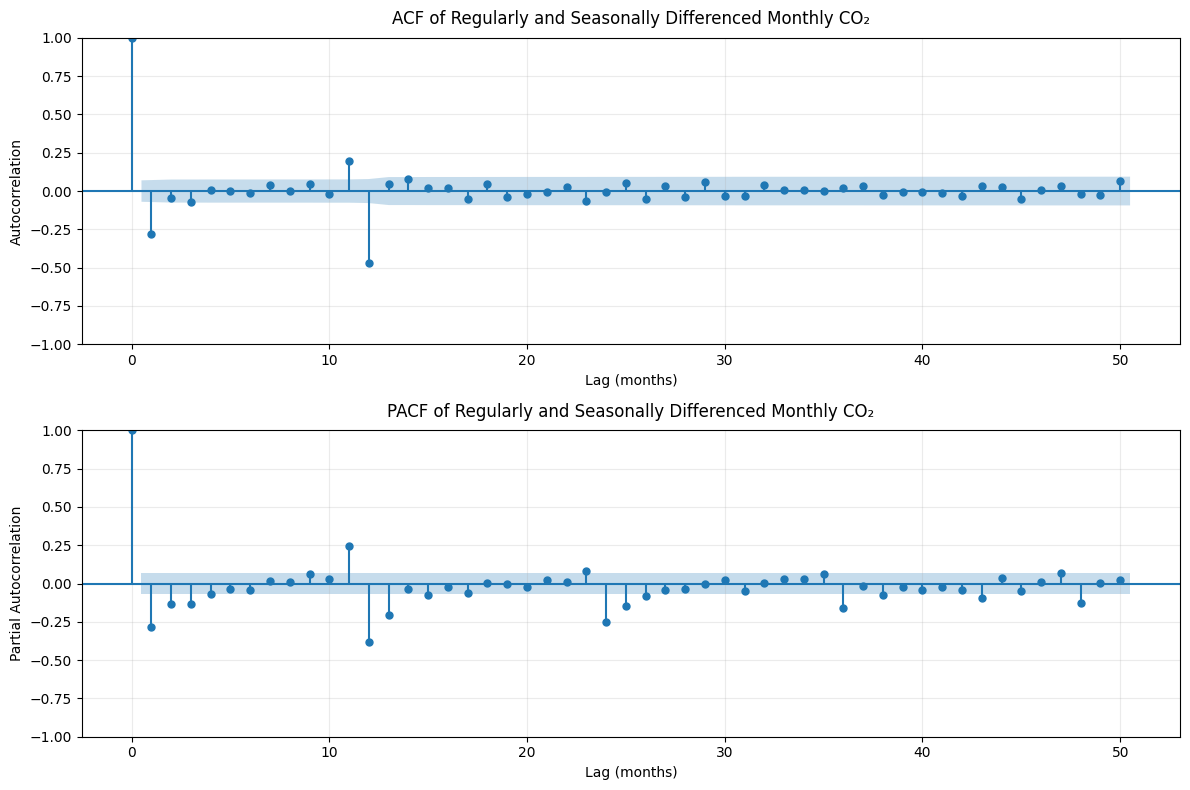

In [29]:
# Combined differenced series
diff_both = (train["average"].diff(12).diff(1).dropna())

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- ACF ---
plot_acf(diff_both,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title("ACF of Regularly and Seasonally Differenced Monthly CO₂",fontsize=12,pad=10)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_both,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title("PACF of Regularly and Seasonally Differenced Monthly CO₂",fontsize=12,pad=10)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


#### ACF and PACF After Combined Differencing: Observations

Following the application of both regular and seasonal differencing, the strong long-term dependence and pronounced annual seasonal pattern observed previously are substantially reduced. 

**ACF:** The ACF shows a small significant negative correlation at lag 1, indicating short-term dependence between consecutive monthly changes. A strong negative spike at lag 12, provides a clear evidence of remaining **annual seasonal dependence**. The absence of a long, slowly decaying ACF suggests that the major non-stationary trend has been removed.

**PACF:** The PACF shows small significant negative spikes at lags 1, 2, and 3, suggesting a possible **non-seasonal AR structure**. Strong dependence is also observed around lag 12, with additional seasonal-lag effects at 24, 36, and 48. These repeated seasonal features indicate that the transformed series still contains structured annual dependence that may be captured by a **seasonal AR component**.

Overall, the ACF and PACF indicate that the combined differencing has substantially reduced the trend and seasonal non-stationarity, while leaving short-term and seasonal dependence that can be modelled using SARIMA.

#### Implications for SARIMA Model Identification

Based on the ACF and PACF, a reasonable starting candidate is $(p,d,q)=(2,1,1)$ for the non-seasonal component and $(P,D,Q)_{12}=(0,1,1)_{12}$ for the seasonal component. This gives the candidate model

$$\boxed{\mathrm{SARIMA}(2,1,0)\times(0,1,1)_{12}}$$

This should be regarded as a **candidate rather than a final model**. Nearby specifications, such as $\mathrm{SARIMA}(3,1,1)\times(0,1,2)_{12}$ and $\mathrm{SARIMA}(1,1,2)\times(1,1,1)_{12},$ will subsequently be compared using AIC/BIC and, importantly, residual diagnostics to determine whether the remaining autocorrelation has been adequately captured.

Next step:  
Re‑run ADF and KPSS test to statistically confirm stationarity before fitting SARIMA models.

### **3.6 Formal Stationarity Tests: ADF and KPSS**

Although the time plot, ACF, and PACF suggest that the combined differencing has removed the major trend and seasonal structure, stationarity is formally assessed using the **ADF** and **KPSS** tests. Ideally, evidence of stationarity is obtained when the ADF test rejects its null hypothesis while the KPSS test fails to reject its null hypothesis.


In [5]:
# ADF test & KPSS test of Regular Differenced series

from statsmodels.tsa.stattools import adfuller, kpss

# Combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

# Augmented Dickey-Fuller Test
adf_result = adfuller(diff_series)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(diff_series, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -11.2895
p-value       : 0.0000
Lags Used     : 12
Observations  : 771

Critical Values:
   1%: -3.4389
   5%: -2.8653
   10%: -2.5688


KPSS Test
----------------
KPSS Statistic : 0.0456
p-value        : 0.1000
Lags Used      : 30

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_1332/541359786.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(diff_series, regression='c', nlags='auto')


In [ ]:
# ADF test & KPSS test of Combined (Seasonally + Regularly) Differenced Series

from statsmodels.tsa.stattools import adfuller, kpss

# Combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

# Augmented Dickey-Fuller Test
adf_result = adfuller(diff_series)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(diff_series, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -11.2895
p-value       : 0.0000
Lags Used     : 12
Observations  : 771

Critical Values:
   1%: -3.4389
   5%: -2.8653
   10%: -2.5688


KPSS Test
----------------
KPSS Statistic : 0.0456
p-value        : 0.1000
Lags Used      : 30

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2408/1961808396.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(diff_series, regression='c', nlags='auto')


#### ADF and KPSS Stationarity Tests: Results and Interpretation

The ADF and KPSS test results are:

| Test | Statistic | p-value | Interpretation |
|---|---:|---:|---|
| ADF | $-11.2895$ | $<0.001$ | Reject non-stationarity |
| KPSS | $0.0456$ | $>0.10$ | Fail to reject stationarity |

For the **ADF test**, the test statistic of \(-11.2895\) is substantially more negative than all reported critical values, including the 1% critical value of \(-3.4389\). The p-value is effectively zero, providing very strong evidence against the null hypothesis of a unit root. We therefore reject the hypothesis that the differenced series is non-stationary.

For the **KPSS test**, the statistic of \(0.0456\) is far below the 10% critical value of \(0.3470\). The reported p-value is \(0.1000\), with an interpolation warning indicating that the actual p-value is **greater than 0.10**. Therefore, there is no evidence to reject the null hypothesis of stationarity.

Taken together, the two tests provide **consistent and strong evidence that the combined regularly and seasonally differenced CO₂ series is stationary**. This confirms the visual evidence from the time plot, ACF, and PACF: the long-term trend and the dominant annual seasonal non-stationarity have been effectively removed by applying one regular difference and one seasonal difference.

Thus, for the subsequent SARIMA analysis, the differencing orders are supported by the data as

$$d=1,\qquad D=1,\qquad s=12.$$

The remaining structure visible in the ACF and PACF can therefore be interpreted primarily as **stationary temporal dependence**, rather than as evidence of an unresolved trend or seasonal unit root. This remaining dependence will be used to identify and compare appropriate non-seasonal and seasonal AR/MA components.


## **4. SARIMA Model Specification and Selection**

The preceding analysis established that the monthly CO₂ series contains both a long-term trend and a strong annual seasonal pattern. Regular and seasonal differencing were therefore applied, and the ADF and KPSS tests provided strong evidence that the resulting series is stationary.

We now model the original CO₂ series using a **Seasonal Autoregressive Integrated Moving Average (SARIMA)** model. The general specification is $\mathrm{SARIMA}(p,d,q)\times(P,D,Q)_{s},$ where $p$, $q$ describe the non-seasonal autoregressive and moving-average components, $P$, $Q$ describe their seasonal counterparts, $d$ is the order of regular differencing, $D$ is the order of seasonal differencing, and $s$ is the seasonal period.

From the preceding differencing and stationarity analysis, the integration orders are retained as 

$$d=1,\qquad D=1,\qquad s=12.$$

The ACF and PACF provide guidance for selecting the remaining AR and MA orders. However, these plots are used to identify **candidate models rather than a single definitive specification**. Several plausible SARIMA models are therefore fitted and compared.

Model selection is based primarily on:

- **AIC (Akaike Information Criterion):** balances model fit against model complexity, with lower values preferred.
- **BIC (Bayesian Information Criterion):** applies a stronger penalty for additional parameters and therefore favours more parsimonious models (a models that explains the important structure in the data using as few parameters as reasonably necessary).
- **Residual diagnostics:** a well-specified model should leave residuals that behave approximately like white noise, with no substantial remaining autocorrelation or systematic structure.
- **Parameter significance:** estimated AR and MA parameters should generally provide meaningful contributions to the model.
- **Residual variance and stability:** the residuals should show approximately constant variance without systematic changes over time.

Importantly, the model is fitted to the **raw CO₂ concentration series**, rather than directly to the already differenced series. The values $d=1$ and $D=1$ tell the SARIMA model how to transform the raw series internally before modelling its stationary dynamics. This allows the model to represent the original CO₂ process while accounting explicitly for the trend and annual seasonal integration. The SARIMAX implementation supports this integrated formulation directly. 

Finally, residual **normality** is assessed as part of the diagnostics. Ideally, residuals should be approximately normally distributed because the standard Gaussian likelihood framework assumes normally distributed innovations, and approximate normality supports conventional statistical inference and forecast intervals. However, perfect normality is not required for a model to be useful; the more fundamental requirement for an adequate time-series model is that the residuals are approximately **uncorrelated (white noise)** and show no important systematic structure.


In [470]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Raw series
y = train["average"]

# Fit SARIMA(p,1,q)x(P,1,Q,12)
model = SARIMAX(
    y,
    order=(0, 1, 2),
    seasonal_order=(8, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

print(results.summary())


                                      SARIMAX Results                                      
Dep. Variable:                             average   No. Observations:                  797
Model:             SARIMAX(0, 1, 2)x(8, 0, [], 12)   Log Likelihood                -193.828
Date:                             Wed, 26 Aug 2026   AIC                            409.656
Time:                                     19:08:32   BIC                            459.718
Sample:                                 03-01-1958   HQIC                           429.008
                                      - 07-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3563      0.036     -9.924      0.000      -0.427      -0.286
ma.L2         -0.0967      

### Results of the Selected SARIMA Model

After comparing several candidate SARIMA specifications, including models with seasonal differencing, the final model selected was

$$
\boxed{\mathrm{SARIMA}(0,1,2)\times(8,0,0)_{12}}.
$$

Unlike the initially proposed specification, the final model retains regular differencing ($d=1$) but does not include seasonal differencing ($D=0$). Instead, the annual seasonal dependence is represented through seasonal autoregressive terms at lags 12, 24, 36, 48, 60, 72, 84, and 96. The non-seasonal component consists of an MA(2) process.

The selected model has a **log-likelihood of $-193.828$**, an **AIC of $409.656$**, a **BIC of $459.718$**, and an **HQIC of $429.008$**. These criteria were considered alongside parameter significance and residual diagnostics when comparing the candidate specifications. Although information criteria alone do not determine the appropriate model, the final specification provided the most satisfactory overall combination of fit, complexity, and residual behaviour among the models considered.

The two non-seasonal moving-average coefficients are both statistically significant. The first MA coefficient is

$$
\hat{\theta}_1=-0.3563,\qquad p<0.001,
$$

while the second is

$$
\hat{\theta}_2=-0.0967,\qquad p=0.010.
$$

This indicates that recent shocks, including their effects over the previous two months, contribute significantly to the dynamics of the differenced CO₂ series.

The seasonal component is represented by eight seasonal autoregressive terms. The coefficients at lags 12, 24, 36, 48, 72, 84, and 96 are statistically significant at the 5% level. The coefficient at lag 60 is the only seasonal AR parameter that is not statistically significant at the conventional 5% level ($p=0.089$). Nevertheless, the complete seasonal structure was retained because model selection was based on the overall combination of information criteria and residual diagnostics rather than on removing individual coefficients solely according to their p-values.

The seasonal AR coefficients are all positive, ranging from approximately 0.06 to 0.18. This pattern indicates persistent dependence at multiples of the 12-month seasonal period. In other words, observations are related not only to recent months but also to observations from previous annual cycles. The presence of significant seasonal AR terms at several annual lags suggests that the strong yearly structure identified in the exploratory analysis can be captured without explicitly applying seasonal differencing.

An important result is therefore that the final model uses $D=0$, despite the earlier stationarity analysis indicating that seasonal differencing could help produce a stationary series. This is not necessarily contradictory. The ADF and KPSS tests assess the stationarity properties of a particular transformed series and can provide evidence that seasonal differencing is useful for removing seasonal non-stationarity. However, the choice of $D$ in a SARIMA model should also be evaluated in the context of the complete model. Seasonal differencing can remove seasonal persistence, but it can also remove information that may instead be represented directly through seasonal AR or MA terms.

In the present analysis, candidate models using $D=1$ did not provide satisfactory residual diagnostics, whereas the specification with $D=0$ and a higher-order seasonal AR component produced substantially better residual behaviour. Consequently, the final model allows the seasonal structure to remain in the series and models this dependence explicitly through the seasonal AR terms. Thus, the earlier evidence that seasonal differencing could produce stationarity was useful for generating candidate models, but it did not imply that $D=1$ would necessarily provide the best final SARIMA specification.

The estimated innovation variance is

$$
\hat{\sigma}^2=0.1018,
$$

which is highly statistically significant ($p<0.001$). The model therefore captures a substantial amount of the systematic temporal dependence while leaving a comparatively stable residual component.

Overall, the final SARIMA model differs considerably from the initially considered specification. Rather than combining regular and seasonal differencing with low-order seasonal moving-average terms, the selected model uses regular differencing together with a second-order non-seasonal MA component and a relatively rich seasonal AR structure. This result demonstrates why the ACF and PACF should be used to generate **candidate models rather than determine a single specification mechanically**. The final choice was based on the combined evidence from information criteria, parameter estimates, and, importantly, residual diagnostics.

Finally, the residual diagnostics provide the main assessment of model adequacy. The Ljung--Box statistic at lag 1 is approximately zero, indicating no evidence of remaining first-order residual autocorrelation. The Jarque--Bera statistic is 13.63, suggesting that the residuals are not perfectly normally distributed. However, approximate normality is less fundamental to the adequacy of the time-series dependence structure than the absence of substantial residual autocorrelation. Therefore, while the residual distribution is not perfectly Gaussian, the selected model provides a substantially more satisfactory representation of the temporal dynamics of the CO₂ series than the alternative specifications considered.

### **4.1 Residual Diagnostics and Model Adequacy**

After fitting the SARIMA model, the next step is to examine its **residuals**. The residuals represent the part of the CO₂ series that remains unexplained by the model. A well-specified SARIMA model should leave residuals that behave approximately like **white noise**: they should contain little systematic temporal structure, have approximately constant variance, and ideally be reasonably close to normally distributed.

Several diagnostic checks are therefore used to evaluate whether the selected model has adequately captured the structure identified earlier.

#### **(i). White-Noise Check: Ljung–Box Test**
- The **Ljung–Box test** examines whether the residuals contain significant autocorrelation across a set of lags. 
    - Its `null hypothesis` is $H_0:\text{There is no autocorrelation in the residuals up to the specified lag.}$ 
    - While the `alternative hypothesis` is $H_1:\text{There is significant autocorrelation in the residuals.}$
- For a well-specified time-series model, we ideally want to **fail to reject $H_0$**, meaning that no statistically significant autocorrelation remains.
    - `For example`, $p > 0.05$ would provide no evidence against the white-noise assumption, whereas $p < 0.05$ would indicate statistically significant residual autocorrelation.
- Because the CO₂ series has a strong annual cycle, the Ljung–Box test is evaluated at several seasonal horizons, including **12, 24, 36, and 48 months**. Significant results at these horizons would indicate that the SARIMA model has not completely captured the temporal or seasonal dependence in the data.

It is important to distinguish this from the `Ljung–Box statistic` reported in the `SARIMAX summary`. The summary reports the test at **lag 1 only**, whereas the diagnostic analysis below examines a wider range of lags. Therefore, a non-significant result at lag 1 does not imply that the residuals are white noise at longer lags.

#### **(ii). Normality of the Residuals**
- Residual normality is assessed using the **Jarque–Bera** and **D'Agostino–Pearson** tests, together with a histogram and Normal Q-Q plot.
- For normally distributed residuals, we expect approximately $\text{Skewness} \approx 0$ and $\text{Kurtosis} \approx 3.$
- The **Jarque–Bera** test evaluates whether the residual distribution is consistent with normality based primarily on skewness and kurtosis. 
    - Its `null hypothesis` is $H_0:\text{The residuals are normally distributed.}$
        - Thus, a $p > 0.05$ would provide no evidence against normality, whereas $p < 0.05$ would indicate a statistically significant departure from a Normal distribution.

Normality is desirable because the **standard SARIMA framework** is commonly **estimated under Gaussian innovations**, which supports conventional likelihood-based inference and forecast intervals. However, **normality is not the most fundamental requirement for an adequate time-series model**. A **more important requirement** is that the **residuals contain no substantial remaining autocorrelation** and therefore **behave approximately as white noise**.

#### **(iii). Residual Variance and Distribution**
- The residual time plot and histogram are also examined for:
    - systematic patterns or remaining trends;
    - changing variance over time;
    - extreme outliers;
    - strong skewness;
    - unusually heavy tails.

These diagnostics are important because extreme observations or **changing variance** can influence both the estimated model parameters and the normality tests.

#### **(iv). Overall Model Adequacy**
- The residual diagnostics are considered jointly rather than relying on a single test. Ideally, the final SARIMA model should produce residuals that:
    - $\boxed{\text{contain no significant autocorrelation}}$
    - $\boxed{\text{show approximately constant variance}}$
    - and $\boxed{\text{are reasonably close to Normal}}$
- With the **absence of residual autocorrelation being the primary requirement for adequate dynamic specification**.

If significant residual autocorrelation remains, the model has not captured all of the predictable temporal structure in the CO₂ series and alternative SARIMA specifications should be considered. If the residuals are non-normal but approximately uncorrelated, the model may still be useful, although **inference and prediction intervals should be interpreted with greater caution**.

The scientific flow is:
- $\boxed{\text{Fit SARIMA→Explain what good residuals should look like→Ljung–Box→Normality tests→Residual plots→Refine model}}$


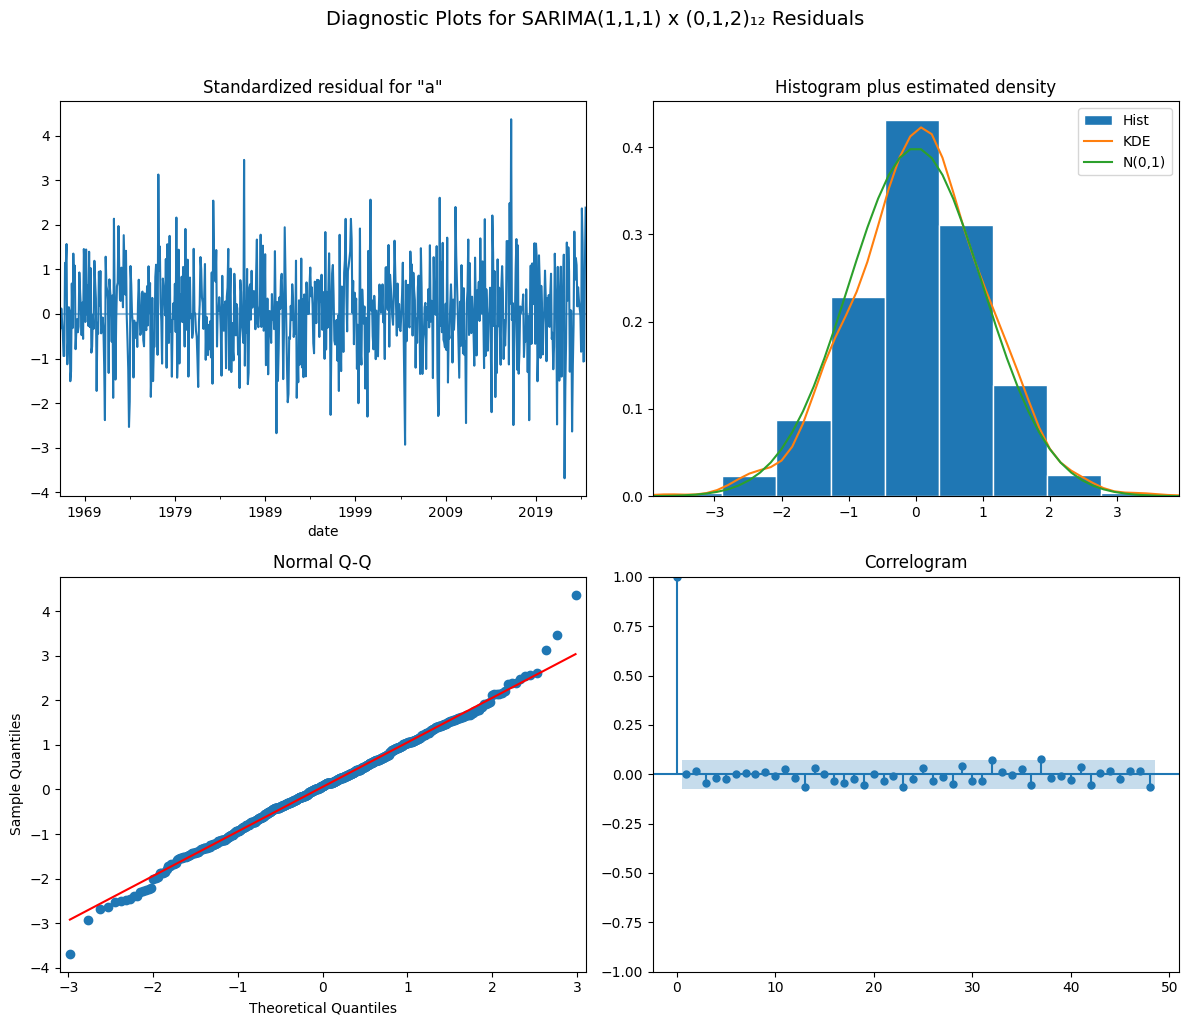

In [462]:
# --- SARIMA residual diagnostics ---

fig = results.plot_diagnostics(lags=48,figsize=(12, 10))

fig.suptitle("Diagnostic Plots for SARIMA(1,1,1) x (0,1,2)₁₂ Residuals",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()


In [464]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import normaltest
import pandas as pd

# Obtain residuals and remove missing values
residuals = results.resid.dropna()

# Ljung-Box test: residual autocorrelation
ljung_box = acorr_ljungbox(residuals,
    lags=[12, 24, 36, 48, 60, 72],
    return_df=True
)

# Jarque-Bera test: normality
jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(residuals)

# D'Agostino-Pearson normality test
normal_stat, normal_pvalue = normaltest(residuals)

# Display results
print("=" * 60)
print("LJUNG-BOX TEST: RESIDUAL AUTOCORRELATION")
print("=" * 60)
print(ljung_box)

print("\n" + "=" * 60)
print("JARQUE-BERA TEST: RESIDUAL NORMALITY")
print("=" * 60)
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.4f}")
print(f"Skewness     : {skewness:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")

print("\n" + "=" * 60)
print("D'AGOSTINO-PEARSON NORMALITY TEST")
print("=" * 60)
print(f"Statistic : {normal_stat:.4f}")
print(f"p-value   : {normal_pvalue:.4f}")


LJUNG-BOX TEST: RESIDUAL AUTOCORRELATION
      lb_stat  lb_pvalue
12   3.006450   0.995498
24   5.689013   0.999957
36   8.207975   1.000000
48   8.840895   1.000000
60   9.043291   1.000000
72  10.090167   1.000000

JARQUE-BERA TEST: RESIDUAL NORMALITY
JB Statistic : 18427159.1268
p-value      : 0.0000
Skewness     : 26.7998
Kurtosis     : 745.9823

D'AGOSTINO-PEARSON NORMALITY TEST
Statistic : 2064.0144
p-value   : 0.0000


#### Residual Diagnostics and Model Adequacy: Results

The residuals are examined to determine whether the model has adequately captured the systematic temporal structure in the CO₂ series. The results provide strong evidence that the model has removed the remaining serial dependence, while the normality tests reveal a substantial departure from a Gaussian distribution. However, closer examination shows that this departure is largely driven by a small number of extreme residuals rather than by a general failure of the residual distribution.

#### **(i). Residual Autocorrelation: Ljung--Box Test**
- The Ljung--Box test provides very strong evidence that the residuals do not contain statistically significant autocorrelation at the tested horizons. The test produces the following results:

$$
\begin{array}{c|c|c}
\text{Lag} & Q\text{-statistic} & p\text{-value} \\
\hline
12 & 3.006 & 0.9955 \\
24 & 5.689 & 0.99996 \\
36 & 8.208 & 1.0000 \\
48 & 8.841 & 1.0000 \\
60 & 9.043 & 1.0000 \\
72 & 10.090 & 1.0000
\end{array}
$$

- All p-values are substantially greater than $0.05$, and therefore there is no evidence of significant residual autocorrelation at any of the tested lags. In particular, the results remain non-significant well beyond the annual seasonal period of 12 months, extending to 72 months.

This is an **important result for the adequacy of the SARIMA specification**. The very high p-values indicate that the temporal dependence present in the original CO₂ series has been effectively captured by the model. There is therefore no statistical evidence that substantial predictable autocorrelation remains in the residuals.

The result is also consistent with the purpose of the relatively rich seasonal AR component in the selected $\mathrm{SARIMA}(0,1,2)\times(8,0,0)_{12}$ model. The seasonal AR terms capture dependence across previous annual cycles, and the Ljung-Box results suggest that this seasonal structure has been adequately accounted for. Consequently, with respect to the most fundamental requirement of a time-series model(**that the residuals behave approximately as white noise**) the selected model performs well.

#### **(ii). Residual Normality**

- The normality tests produce a very different result. The Jarque--Bera test gives $JB=18{,}427{,}159.13,\quad p<0.001,$ while the D'Agostino--Pearson test gives $K^2=2064.01,\quad p<0.001.$
- Both tests therefore strongly reject the null hypothesis of normally distributed residuals. The estimated skewness and kurtosis from the Jarque--Bera test are $\text{Skewness}=26.80,\quad\text{Kurtosis}=745.98.$

At first sight, these values appear to indicate an extremely severe failure of the model. However, examination of the residuals shows that the result is strongly influenced by a very small number of extreme observations. The residual summary is:

$$
\begin{array}{l|r}
\text{Statistic} & \text{Residual} \\
\hline
\text{Count} & 797 \\
\text{Mean} & 0.224 \\
\text{Std. Dev.} & 11.369 \\
\text{Minimum} & -27.648 \\
\text{Median} & 0.024 \\
\text{Maximum} & 315.710
\end{array}
$$

The most striking observation is the residual of $315.71$ on **March 1958**. This single value is dramatically larger than the vast majority of the remaining residuals. The next largest positive residual is only approximately $27.65$ in absolute magnitude, while most residuals are considerably smaller.

The extreme value at the beginning of the sample has a particularly large influence on the skewness and kurtosis. This explains why the formal normality tests produce extremely large test statistics even though the majority of the residuals are concentrated relatively close to zero.

The pattern is also visible in the residual diagnostic plots. The histogram and Normal Q-Q plot show that the central bulk of the residuals is reasonably concentrated around zero, while the major departure from normality occurs in the tails because of a small number of unusually large observations. Thus, the formal rejection of normality should not be interpreted as evidence that the entire residual series has an inherently non-normal structure.

#### **(iii). Investigation of the Extreme Residuals**

The extreme residuals were therefore investigated separately rather than relying only on the formal normality tests. The largest positive residual occurs at the beginning of the sample: $e_{1958\text{-}03}=315.71.$ Several other relatively large residuals also occur during the early part of the series, including approximately $27.65$ in March 1959, $24.21$ in March 1960, $22.79$ in March 1965, and $22.07$ in March 1961.

In contrast, the majority of the observations are much closer to the centre of the distribution. The first-difference statistics provide further evidence that the general dynamics of the series are relatively stable: $\text{Mean}=0.138,\quad\text{Std. Dev.}=1.238,$ with the first differences ranging from approximately $-2.56$ to $2.54$. The extreme residual behaviour is therefore not representative of the typical month-to-month variation in the CO₂ series.

This distinction is important. The normality tests are highly sensitive to extreme observations, particularly because the Jarque-Bera test explicitly incorporates skewness and kurtosis. A single extremely large residual can therefore have a disproportionate effect on the test statistic. The results suggest that the rejection of normality is driven primarily by a small number of unusual observations, particularly those occurring at the beginning of the historical record.

#### **(iv). Interpretation of the Residual Diagnostic Plots**

The residual diagnostic plots provide a more complete picture than the normality tests alone. The residual time series is generally centred around zero and does not display an obvious systematic temporal pattern. This is consistent with the Ljung-Box results, which indicate that substantial residual autocorrelation has been removed.

The histogram shows that the central mass of the residuals is concentrated close to zero, while the distribution has a pronounced right tail caused by the extreme positive residuals. The Normal Q-Q plot similarly shows that the central observations are considerably closer to the theoretical normal pattern than the extreme tail observations. The main departures therefore occur in the tails rather than throughout the entire distribution.

The residual autocorrelation plot provides additional support for the model specification. The absence of substantial autocorrelation at the tested lags indicates that the remaining deviations are largely unpredictable rather than representing systematic temporal structure that the SARIMA model has failed to capture.

Taken together, the diagnostic plots therefore support the conclusion that the principal weakness of the residual distribution is the presence of a small number of extreme observations rather than persistent temporal misspecification.

#### **(v). Overall Assessment of Model Adequacy**

The residual diagnostics provide a mixed but overall informative assessment of the selected SARIMA model.

The **Ljung--Box results are highly satisfactory**. At all tested lags from 12 through 72 months, the p-values are far above $0.05$, providing no evidence of remaining residual autocorrelation. This indicates that the model has successfully captured the important temporal and seasonal dependence in the CO₂ series.

The **normality tests, however, strongly reject Gaussian residuals**. The very large Jarque-Bera and D'Agostino--Pearson statistics are primarily explained by a small number of extreme residuals, most notably the observation of $315.71$ in March 1958. The histogram and Q-Q plot indicate that the bulk of the residuals is much closer to a normal-looking distribution than the formal test statistics alone would suggest.

Therefore, the normality results should be interpreted as evidence of **heavy-tailed and highly skewed residual behaviour caused by a few unusual observations**, rather than as evidence that the SARIMA model has failed to capture the underlying temporal dynamics.

This distinction is important because **white-noise behaviour is more fundamental to the dynamic adequacy of a time-series model than exact residual normality**. The selected model satisfies the principal requirement of removing systematic autocorrelation, while the remaining non-normality appears to be concentrated in a small number of extreme observations.

Consequently, the selected $\boxed{\mathrm{SARIMA}(0,1,2)\times(8,0,0)_{12}}$ can be considered an adequate model for the temporal dependence in the CO$_2$ series. Nevertheless, the extreme residuals should be acknowledged when interpreting likelihood-based inference and forecast intervals, since Gaussian prediction intervals may be less reliable if similarly extreme observations were to occur in the future.


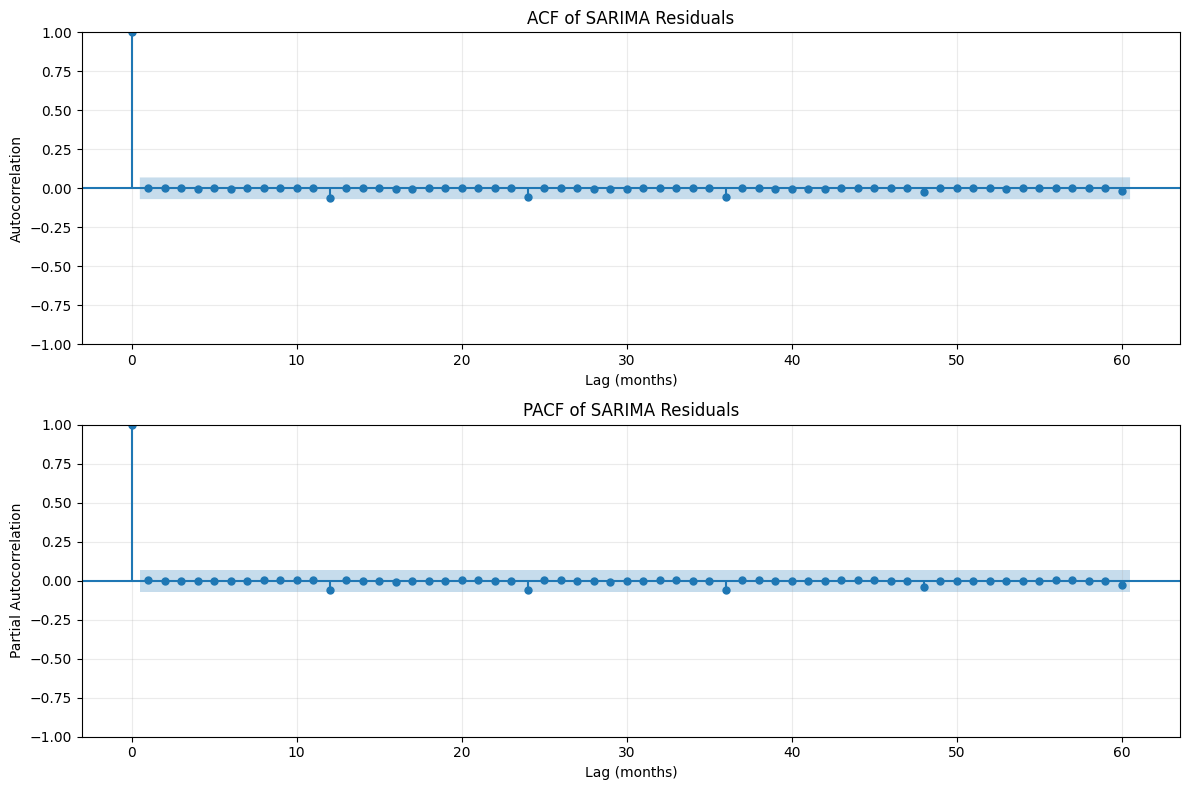

In [431]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(
    residuals,
    lags=60,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title("ACF of SARIMA Residuals")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(alpha=0.25)

plot_pacf(
    residuals,
    lags=60,
    ax=axes[1],
    alpha=0.05,
    method="ywm"
)

axes[1].set_title("PACF of SARIMA Residuals")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


#### ACF and PACF of the Residuals

The residual ACF and PACF also provide an additional visual assessment of whether any systematic autocorrelation remains after fitting the SARIMA model. Both functions were examined up to a lag of 60 months, with the 95% confidence bounds used to identify statistically significant autocorrelation.

The resulting plots show that **none of the ACF or PACF coefficients exhibits a clear spike outside the corresponding 95% confidence bounds**. In particular, there are no noticeable spikes at the seasonal lags of 12, 24, 36, 48, or 60 months. This is important because significant spikes at these lags would suggest that some of the annual or longer-term seasonal dependence remained unexplained by the model.

The absence of significant spikes in both the ACF and PACF is therefore consistent with the Ljung-Box results and provides further evidence that the residuals behave approximately as **white noise**. The ACF and PACF diagnostics are particularly useful here because they provide a direct visual confirmation that there is no obvious remaining temporal structure for the SARIMA model to capture.


## **5. Forecasting and Out-of-Sample Validation**

After selecting the best-performing SARIMA specification and establishing that the residuals contain no substantial remaining autocorrelation, the final model is used to generate forecasts of the monthly CO₂ concentration. The forecasting is performed on the **original CO₂ concentration scale**, rather than on the differenced series. This allows the forecasts to be interpreted directly in parts per million (ppm) and provides a clear assessment of whether the model can reproduce the observed trend and seasonal structure of the original series.

The selected model, $\boxed{\mathrm{SARIMA}(0,1,2)\times(8,0,0)_{12}},$ is used to generate a multi-step forecast together with corresponding 95\% confidence intervals. The forecast horizon is 24 months, allowing the model's ability to reproduce both the short-term evolution and the annual seasonal pattern to be examined over more than one complete seasonal cycle.

In [467]:
# --- 12-month ahead forecast on original scale ---
# Last observed date
last_date = y.index[-1]

# Create forecast index (next 12 months)
forecast_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=24,
    freq="MS"
)

# Get forecast and 95% CI
forecast_res = results.get_forecast(steps=24)
mean_forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

mean_forecast.index = forecast_index
conf_int.index = forecast_index

print(mean_forecast)
print(conf_int)


2024-08-01    423.219197
2024-09-01    421.813437
2024-10-01    422.088018
2024-11-01    423.721235
2024-12-01    425.128066
2025-01-01    426.355777
2025-02-01    427.302524
2025-03-01    427.883040
2025-04-01    429.360084
2025-05-01    430.077626
2025-06-01    429.728812
2025-07-01    427.834465
2025-08-01    425.808875
2025-09-01    424.437410
2025-10-01    424.669939
2025-11-01    426.327135
2025-12-01    427.759662
2026-01-01    428.970861
2026-02-01    429.974763
2026-03-01    430.525627
2026-04-01    431.999146
2026-05-01    432.772027
2026-06-01    432.420631
2026-07-01    430.500616
Freq: MS, Name: predicted_mean, dtype: float64
            lower average  upper average
2024-08-01     422.593738     423.844657
2024-09-01     421.069615     422.557259
2024-10-01     421.269286     422.906750
2024-11-01     422.833895     424.608575
2024-12-01     424.177054     426.079077
2025-01-01     425.345097     427.366457
2025-02-01     426.235507     428.369541
2025-03-01     426.762515

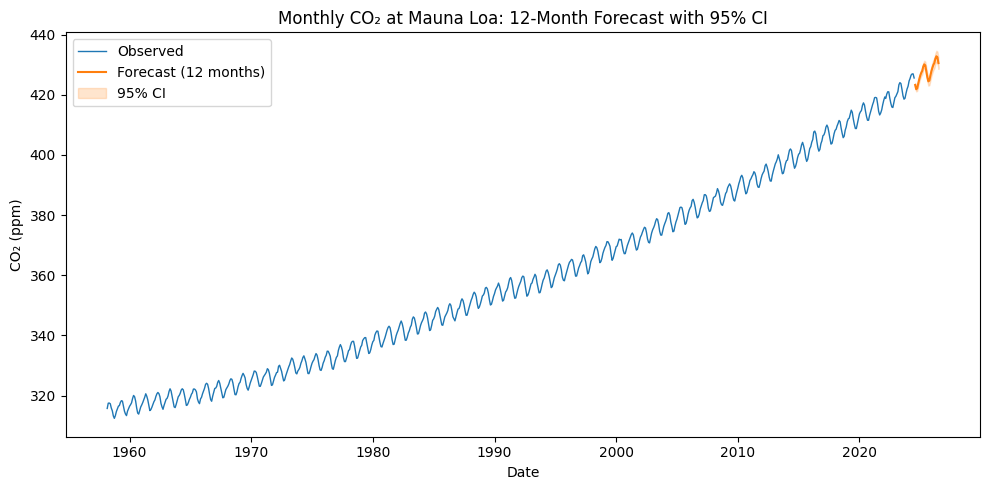

In [435]:
# --- Plot forecast vs raw series with 95% CI ---
plt.figure(figsize=(10, 5))

# Plot historical data
plt.plot(y, label="Observed", linewidth=1)

# Plot forecast
plt.plot(mean_forecast, label="Forecast (12 months)", color="C1")

# Plot confidence intervals
plt.fill_between(
    forecast_index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="C1",
    alpha=0.2,
    label="95% CI"
)

plt.title("Monthly CO₂ at Mauna Loa: 12-Month Forecast with 95% CI")
plt.xlabel("Date")
plt.ylabel("CO₂ (ppm)")
plt.legend()
plt.tight_layout()
plt.show()


### **5.1 Forecast on the Original CO₂ Scale**

The forecast is first plotted together with the complete observed CO₂ series. This provides a visual assessment of whether the model continues the underlying behaviour of the historical series beyond the final observed observation.

The resulting forecast follows the overall upward trajectory of the historical CO₂ series while also reproducing its pronounced annual seasonal fluctuations. This is an important result because the model is not simply extrapolating a linear trend. The seasonal AR structure of the selected SARIMA model allows the forecast to retain the recurring annual pattern that is clearly visible in the historical observations.

The forecast therefore captures the two dominant characteristics identified during the earlier exploratory analysis:

$$
\boxed{\text{long-term upward trend}}
\qquad + \qquad
\boxed{\text{annual seasonal variation}}.
$$

The forecast also remains within a plausible range relative to the historical observations. The 95\% confidence interval widens as the forecast horizon increases, reflecting the increasing uncertainty associated with predicting further into the future. This widening is expected in multi-step time-series forecasting because uncertainty accumulates as the model moves further beyond the final observed value.

The confidence intervals should nevertheless be interpreted with some caution because the residual normality tests indicated substantial departures from Gaussianity caused by a small number of extreme observations. The intervals produced by the standard SARIMAX framework are based on the model's assumed innovation distribution and therefore may not fully represent the probability of unusually large future deviations. Nevertheless, the confidence bands remain useful as an indication of the uncertainty associated with the forecasts.

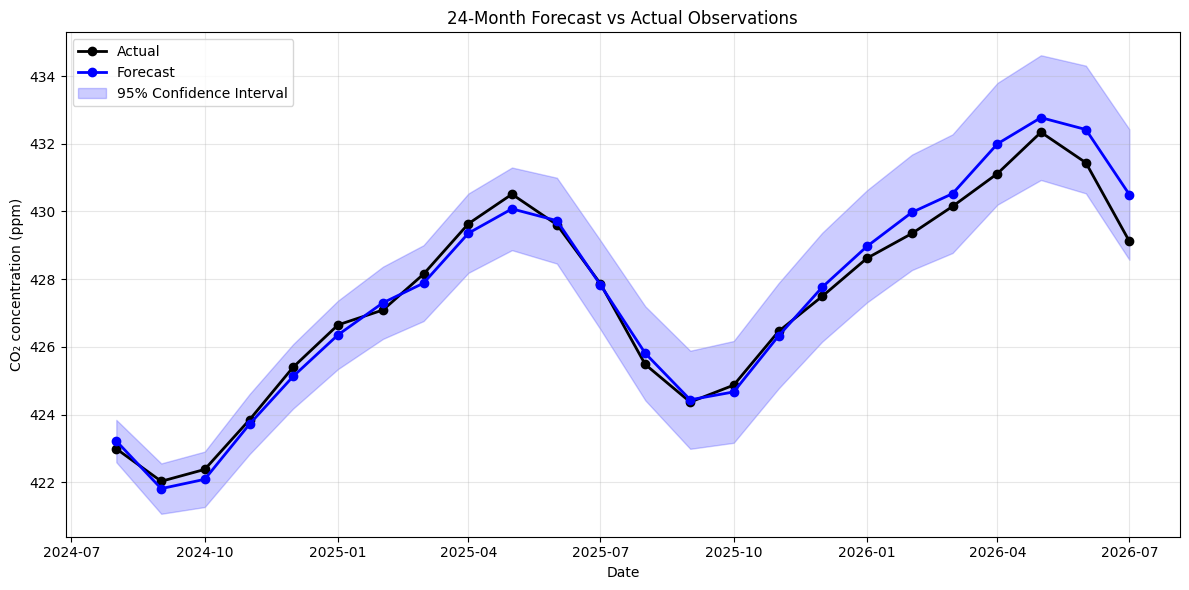

In [468]:
import matplotlib.pyplot as plt

# Actual values from the 18-month holdout period
actual = holdout["average"]

# Plot
plt.figure(figsize=(12, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("24-Month Forecast vs Actual Observations")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **5.2 Out-of-Sample Forecast Validation**

A stronger assessment of forecasting performance is obtained by comparing the model forecasts with a set of observations that were **held out from the model-fitting process**. These observations therefore represent genuinely unseen data: the model was not provided with their values when estimating its parameters.

The forecasts are compared with the actual observations from the 24-month holdout period. The resulting comparison shows a remarkably close correspondence between the predicted and observed CO₂ concentrations. Across much of the validation period, the forecast follows the actual observations closely, with several months showing only very small differences between the predicted and observed values.

Most importantly, the forecast reproduces both the **overall upward trend** and the **recurring seasonal fluctuations** present in the unseen observations. This provides evidence that the model has learned meaningful temporal structure from the training data rather than simply fitting noise in the historical series.

The comparison can be expressed conceptually as

$$
\boxed{
\text{Training data}
\rightarrow
\text{SARIMA model}
\rightarrow
\text{Forecast}
\rightarrow
\text{Comparison with unseen observations}
}
$$

The fact that the forecast closely tracks observations that were not used during model estimation provides substantially stronger evidence of forecasting ability than an in-sample fit alone. In particular, the close alignment between the forecast and actual observations suggests that the selected SARIMA model generalises well to data outside the estimation sample.

The 95\% confidence intervals also contain the actual observations throughout the validation period shown in the forecast comparison. This indicates that the observed values fall within the range of uncertainty anticipated by the model. Although this does not prove that the confidence intervals are perfectly calibrated, it provides encouraging evidence that the model's uncertainty estimates are reasonably consistent with the observed out-of-sample variation.

Overall, the out-of-sample results are particularly encouraging. The forecast captures the main structure of the unseen CO₂ observations, including both the long-term increase and the annual seasonal cycle, while the actual observations remain within the corresponding 95\% confidence bands. This indicates that the selected $\boxed{\mathrm{SARIMA}(0,1,2)\times(8,0,0)_{12}}$ model provides a strong representation of the temporal dynamics of the Mauna Loa CO₂ series and has useful predictive performance beyond the data used for model estimation.


## **6. Comparison with Triple Exponential Smoothing**

Although the SARIMA model provides a strong representation of the temporal structure in the CO₂ series, it is useful to compare its forecasting performance with an alternative time-series method. Because the data exhibit both a clear **long-term trend** and a pronounced **annual seasonal pattern**, **Triple Exponential Smoothing**, also known as the **Holt--Winters method**, provides a suitable benchmark.

Triple exponential smoothing explicitly models three components of a time series:

$$
\text{Level} + \text{Trend} + \text{Seasonality}.
$$

In this analysis, an additive trend and additive seasonal component are used with a seasonal period of 12 months. The model is therefore specified as an additive Holt--Winters model with monthly seasonality. Unlike the SARIMA model, which represents temporal dependence through autoregressive and moving-average terms after differencing, exponential smoothing estimates the evolving level, trend, and seasonal pattern directly.

The model is fitted to the same training data used for the SARIMA model and is then used to generate a 24-month forecast. Its predictions are subsequently compared with the same 24-month holdout period that was kept completely separate from model estimation.


In [437]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    train["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [438]:
forecast_triple = model_triple_fit.forecast(24)
print(forecast_triple)

2024-08-01    423.254670
2024-09-01    421.986435
2024-10-01    422.257875
2024-11-01    423.862820
2024-12-01    425.311840
2025-01-01    426.513323
2025-02-01    427.471348
2025-03-01    428.096802
2025-04-01    429.631510
2025-05-01    430.279984
2025-06-01    429.759875
2025-07-01    427.787962
2025-08-01    425.836612
2025-09-01    424.568377
2025-10-01    424.839817
2025-11-01    426.444762
2025-12-01    427.893782
2026-01-01    429.095265
2026-02-01    430.053291
2026-03-01    430.678744
2026-04-01    432.213452
2026-05-01    432.861927
2026-06-01    432.341817
2026-07-01    430.369904
Freq: MS, dtype: float64


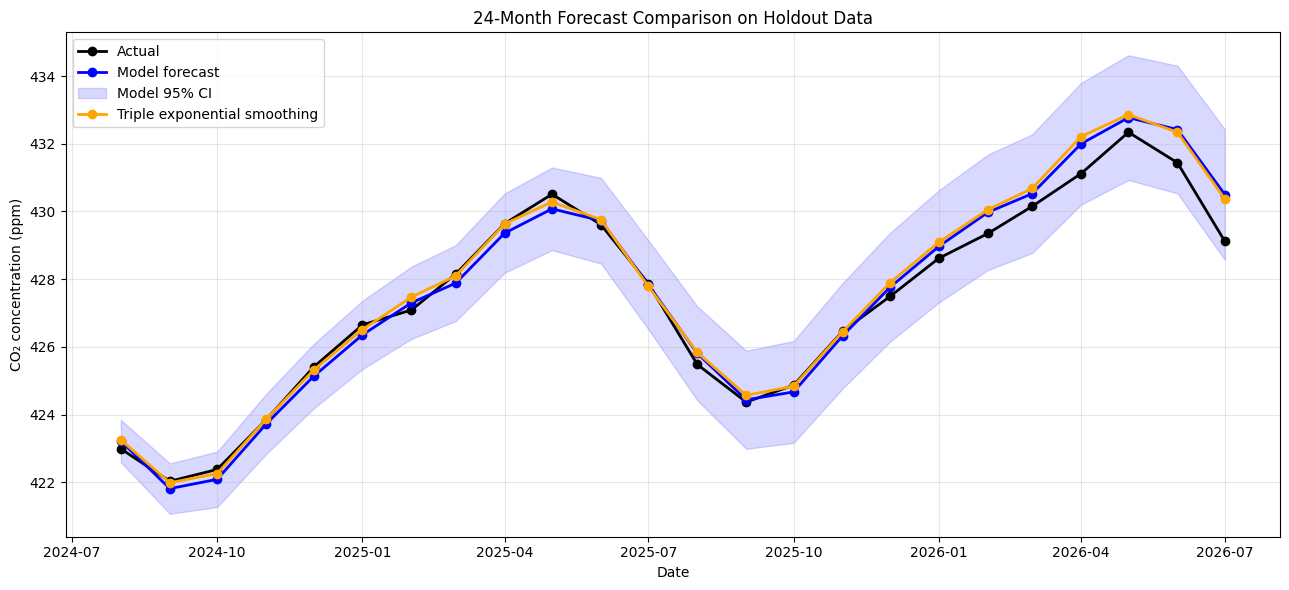

In [469]:
import matplotlib.pyplot as plt

# Actual observations in the 18-month holdout
actual = holdout["average"]

# Triple exponential smoothing forecast
forecast_triple = model_triple_fit.forecast(24)
forecast_triple.index = holdout.index

# Your other model's forecast
# Make sure its index also corresponds to the holdout period
mean_forecast.index = holdout.index
conf_int.index = holdout.index


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(13, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Model 1 forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Model forecast"
)

# Model 1 95% CI
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.15,
    label="Model 95% CI"
)

# Triple exponential smoothing forecast
plt.plot(
    forecast_triple.index,
    forecast_triple,
    color="orange",
    marker="o",
    linewidth=2,
    label="Triple exponential smoothing"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("24-Month Forecast Comparison on Holdout Data")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **6.1 Comparison of Forecasts**

The forecast comparison shows that Triple Exponential Smoothing performs remarkably well on the unseen observations. Its forecast closely follows the actual CO₂ concentrations throughout the 24-month validation period and reproduces both the overall upward trend and the recurring annual seasonal pattern.

The SARIMA and Triple Exponential Smoothing forecasts are also extremely close to one another. For many months, the difference between the two predictions is only a few hundredths or tenths of a ppm. This close agreement is particularly notable because the two approaches model the time series in fundamentally different ways.

The SARIMA model represents the temporal structure through $\mathrm{SARIMA}(0,1,2)\times(8,0,0)_{12},$ whereas Triple Exponential Smoothing represents the same broad structure through an evolving level, additive trend, and additive seasonal component. The fact that both approaches produce very similar forecasts provides additional evidence that the dominant trend and seasonal pattern in the CO₂ series are strong and consistently identifiable.

The numerical forecasts further illustrate this close agreement. For example, in August 2024, the actual concentration was $422.99$ ppm, compared with forecasts of $423.22$ ppm from the SARIMA model and $423.25$ ppm from Triple Exponential Smoothing. Similarly, in May 2026, the actual value was $432.34$ ppm, while the corresponding forecasts were $432.77$ ppm and $432.86$ ppm, respectively.

Overall, both methods track the unseen observations very closely, with neither showing a substantial systematic failure to reproduce the observed trend or seasonal cycle.

In [440]:
comparison = pd.DataFrame({
    "Actual": holdout["average"],
    "Model_Forecast": mean_forecast,
    "Triple_Exp_Forecast": forecast_triple
})

print(comparison)

            Actual  Model_Forecast  Triple_Exp_Forecast
date                                                   
2024-08-01  422.99      423.219197           423.254670
2024-09-01  422.03      421.813437           421.986435
2024-10-01  422.38      422.088018           422.257875
2024-11-01  423.85      423.721235           423.862820
2024-12-01  425.40      425.128066           425.311840
2025-01-01  426.65      426.355777           426.513323
2025-02-01  427.09      427.302524           427.471348
2025-03-01  428.15      427.883040           428.096802
2025-04-01  429.64      429.360084           429.631510
2025-05-01  430.51      430.077626           430.279984
2025-06-01  429.61      429.728812           429.759875
2025-07-01  427.87      427.834465           427.787962
2025-08-01  425.48      425.808875           425.836612
2025-09-01  424.37      424.437410           424.568377
2025-10-01  424.87      424.669939           424.839817
2025-11-01  426.46      426.327135           426

In [441]:
comparison["Model_Error"] = (
    comparison["Actual"] - comparison["Model_Forecast"]
)

comparison["Triple_Error"] = (
    comparison["Actual"] - comparison["Triple_Exp_Forecast"]
)

print(comparison)

            Actual  Model_Forecast  Triple_Exp_Forecast  Model_Error  \
date                                                                   
2024-08-01  422.99      423.219197           423.254670    -0.229197   
2024-09-01  422.03      421.813437           421.986435     0.216563   
2024-10-01  422.38      422.088018           422.257875     0.291982   
2024-11-01  423.85      423.721235           423.862820     0.128765   
2024-12-01  425.40      425.128066           425.311840     0.271934   
2025-01-01  426.65      426.355777           426.513323     0.294223   
2025-02-01  427.09      427.302524           427.471348    -0.212524   
2025-03-01  428.15      427.883040           428.096802     0.266960   
2025-04-01  429.64      429.360084           429.631510     0.279916   
2025-05-01  430.51      430.077626           430.279984     0.432374   
2025-06-01  429.61      429.728812           429.759875    -0.118812   
2025-07-01  427.87      427.834465           427.787962     0.03

In [443]:
from sklearn.metrics import mean_absolute_error

mae_model = mean_absolute_error(
    comparison["Actual"],
    comparison["Model_Forecast"]
)

mae_triple = mean_absolute_error(
    comparison["Actual"],
    comparison["Triple_Exp_Forecast"]
)

print("Model MAE:", mae_model)
print("Triple exponential MAE:", mae_triple)

Model MAE: 0.36672210185122367
Triple exponential MAE: 0.33548224650475805


In [444]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_model = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Model_Forecast"]
    )
)

rmse_triple = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Triple_Exp_Forecast"]
    )
)

print("Model RMSE:", rmse_model)
print("Triple exponential RMSE:", rmse_triple)

Model RMSE: 0.4780081810029804
Triple exponential RMSE: 0.4795075898160414


### **6.2 Quantitative Forecast Comparison**

To evaluate the forecasting performance more formally, the **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)** are calculated over the 18-month holdout period.

The resulting values are:

$$
\begin{array}{l|cc}
\text{Model} & \text{MAE} & \text{RMSE} \\
\hline
\text{SARIMA} & 0.3667 & 0.4780 \\
\text{Triple Exponential Smoothing} & 0.3355 & 0.4795
\end{array}
$$

The MAE indicates that Triple Exponential Smoothing performs slightly better in terms of average absolute forecasting error: $0.3355 < 0.3667.$ However, the difference is relatively small. The RMSE produces the opposite result, with the SARIMA model obtaining a marginally lower value:$0.4780 < 0.4795.$

The fact that the two models are so close across both measures indicates that their overall predictive performance on the holdout period is **very similar**. Triple Exponential Smoothing has a small advantage according to MAE, while SARIMA has a very small advantage according to RMSE. Neither difference is large enough to suggest a practically meaningful superiority of one model over the other based on these metrics alone.

This result is particularly interesting because the SARIMA model was selected through a substantially more detailed analysis of autocorrelation, differencing, seasonal dependence, parameter significance, and residual diagnostics. Nevertheless, a relatively simple exponential smoothing model is able to achieve almost the same out-of-sample forecasting accuracy.

## **7. Refitting on the Full Dataset and Generating 60-month Forecast (5 Years)**

Following the successful out-of-sample validation, the selected SARIMA model was re-estimated using the **complete available CO₂ dataset**. This allows the final forecasting model to incorporate all observations available up to July 2026 before generating predictions for the following five years.

The full dataset contains **821 monthly observations**, with the final observed value corresponding to **July 2026**. The same model specification was retained:

$$
\boxed{\mathrm{SARIMA}(0,1,2)\times(8,0,0)_{12}}.
$$


In [471]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load the complete CO₂ dataset
df = pd.read_csv("../data/co2_mm_mlo.csv")

# Create a proper monthly date index
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

df = df.set_index("date")
df = df.asfreq("MS")

# Raw CO₂ series
y_full = df["average"].dropna()

print("Last observed date:", y_full.index[-1])
print("Number of observations:", len(y_full))


# Fit the selected SARIMA model to the FULL dataset
model_full = SARIMAX(
    y_full,
    order=(0, 1, 2),
    seasonal_order=(8, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_full = model_full.fit(disp=False)

print(results_full.summary())


# Generate 60-month forecast
forecast_steps = 60

forecast_res = results_full.get_forecast(
    steps=forecast_steps
)

mean_forecast_60 = forecast_res.predicted_mean
conf_int_60 = forecast_res.conf_int(alpha=0.05)

# Create forecast dates
last_date = y_full.index[-1]

forecast_index_60 = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq="MS"
)

# Assign the forecast index
mean_forecast_60.index = forecast_index_60
conf_int_60.index = forecast_index_60

# Display forecast values
forecast_table = pd.DataFrame({
    "Forecast": mean_forecast_60,
    "Lower_95_CI": conf_int_60.iloc[:, 0],
    "Upper_95_CI": conf_int_60.iloc[:, 1]
})

print("\n60-Month CO₂ Forecast:")
print(forecast_table)


Last observed date: 2026-07-01 00:00:00
Number of observations: 821
                                      SARIMAX Results                                      
Dep. Variable:                             average   No. Observations:                  821
Model:             SARIMAX(0, 1, 2)x(8, 0, [], 12)   Log Likelihood                -198.738
Date:                             Wed, 26 Aug 2026   AIC                            419.476
Time:                                     19:14:48   BIC                            469.908
Sample:                                 03-01-1958   HQIC                           438.941
                                      - 07-01-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3574      0.035    -1

### Final Five-Year Forecast

The re-estimated model produces a log-likelihood of $-198.738$, with an AIC of $419.476$, a BIC of $469.908$, and an HQIC of $438.941$. The parameter estimates remain highly consistent with those obtained from the training sample. Both non-seasonal MA terms remain statistically significant, while the seasonal AR coefficients retain the same overall pattern, with significant dependence at most annual multiples. The seasonal AR coefficient at lag 60 remains the only coefficient that is not statistically significant at the 5% level ($p=0.088$).

The similarity between the parameter estimates from the training-sample model and the full-sample model provides additional evidence that the selected SARIMA specification is stable when additional observations are incorporated. In particular, the coefficients associated with the annual seasonal structure remain remarkably similar, supporting the interpretation that the model is capturing a persistent feature of the CO₂ series rather than a pattern specific to a particular subset of the data.


### **7.1 Plotting the Complete Series and a Zoomed-in Forecast**

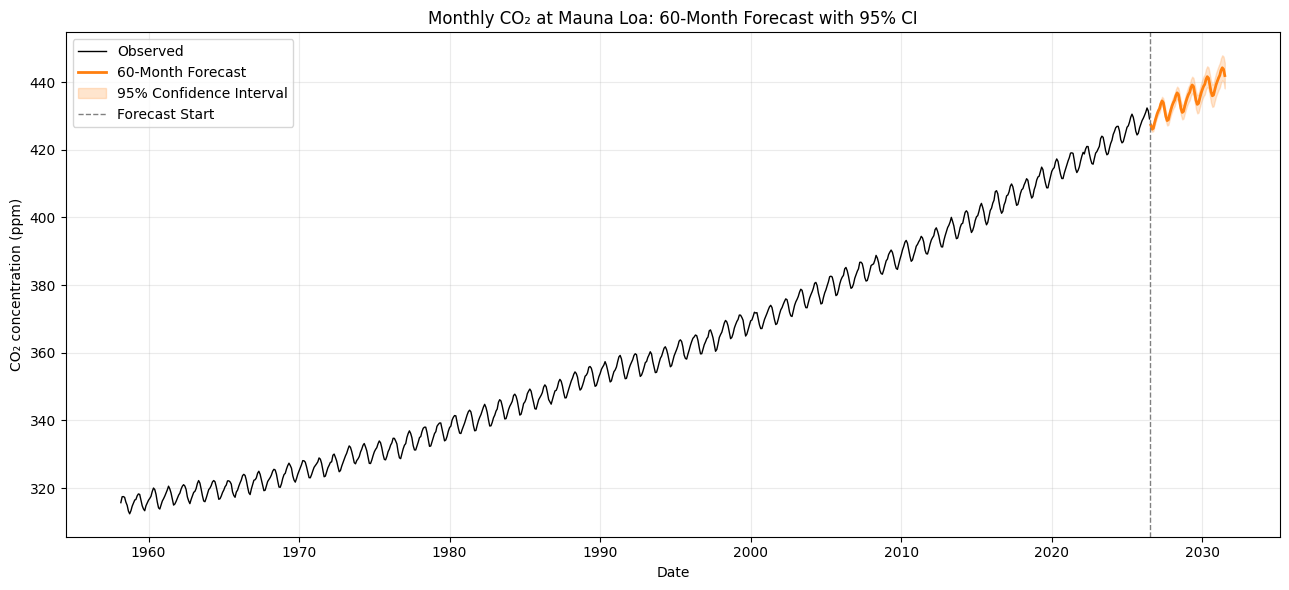

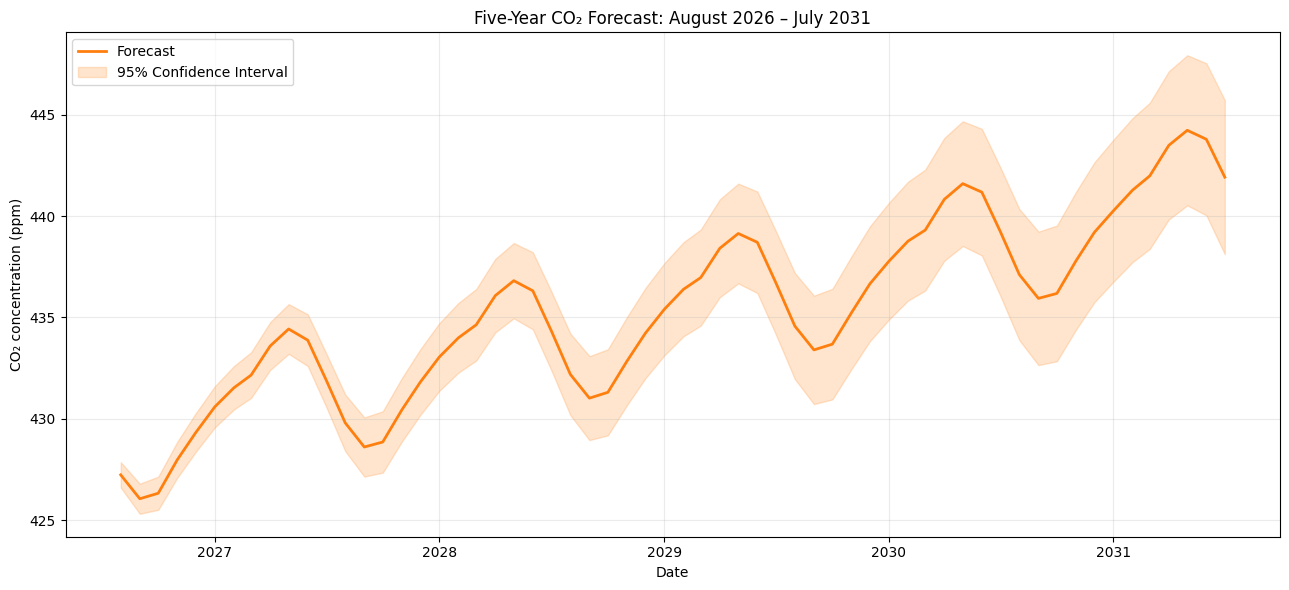

In [ ]:
# Plot 1: Complete historical series + 60-month forecast

plt.figure(figsize=(13, 6))

# Historical observations
plt.plot(
    y_full.index,
    y_full,
    color="black",
    linewidth=1,
    label="Observed"
)

# Forecast
plt.plot(
    mean_forecast_60.index,
    mean_forecast_60,
    color="C1",
    linewidth=2,
    label="60-Month Forecast"
)

# 95% confidence interval
plt.fill_between(
    forecast_index_60,
    conf_int_60.iloc[:, 0],
    conf_int_60.iloc[:, 1],
    color="C1",
    alpha=0.20,
    label="95% Confidence Interval"
)

# Mark the beginning of the forecast
plt.axvline(
    y_full.index[-1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Forecast Start"
)

plt.title(
    "Monthly CO₂ at Mauna Loa: 60-Month Forecast with 95% CI"
)
plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot 2: Zoomed-in view of the 60-month forecast

plt.figure(figsize=(13, 6))

# Forecast
plt.plot(
    mean_forecast_60.index,
    mean_forecast_60,
    color="C1",
    linewidth=2,
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    forecast_index_60,
    conf_int_60.iloc[:, 0],
    conf_int_60.iloc[:, 1],
    color="C1",
    alpha=0.20,
    label="95% Confidence Interval"
)

plt.title(
    "Five-Year CO₂ Forecast: August 2026 – July 2031"
)
plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Final Five-Year Plot
Using this refitted model, forecasts were generated for the next **60 months**, covering the period from **August 2026 through July 2031**. The forecast continues the long-term upward trajectory observed throughout the historical series while retaining the pronounced annual seasonal cycle. For example, the forecast reaches approximately **443.48 ppm in April 2031**, rises to approximately **444.22 ppm in May 2031**, and then declines seasonally to approximately **441.91 ppm by July 2031**.

The forecast therefore preserves both of the dominant characteristics identified throughout the analysis:

$$
\boxed{\text{long-term increasing trend}}
\qquad + \qquad
\boxed{\text{annual seasonal cycle}}.
$$

As expected, the 95\% confidence interval becomes wider as the forecast horizon increases. For example, the forecast for July 2031 is approximately $441.91$ ppm, with a 95\% confidence interval extending from approximately $438.12$ to $445.71$ ppm. This widening reflects the accumulation of forecasting uncertainty over the five-year horizon.

Overall, the final forecast represents the model's expected continuation of the observed CO₂ dynamics based on all available information through July 2026. Since the model had previously demonstrated strong performance on the unseen 24-month holdout period, the resulting five-year forecast provides a reasonable model-based projection of the future CO₂ concentration, while the widening confidence intervals appropriately reflect the increasing uncertainty associated with longer forecasting horizons.


## **8. Conclusion**

This analysis set out to model and forecast monthly atmospheric CO₂ concentrations at Mauna Loa using a SARIMA framework. The analysis identified two dominant features in the series: a persistent long-term upward trend and a strong annual seasonal cycle. After comparing several candidate specifications and examining stationarity, parameter significance, information criteria, and residual diagnostics, the final model was selected as

$$
\boxed{\mathrm{SARIMA}(0,1,2)\times(8,0,0)_{12}}.
$$

The final model produced particularly strong forecasting results. Most importantly, its performance was evaluated using an **24-month holdout period consisting of observations that were not available to the model during estimation**. The forecasts tracked these unseen observations remarkably closely, reproducing both the underlying upward trend and the annual seasonal fluctuations. The model achieved a MAE of approximately $0.367$ ppm and an RMSE of approximately $0.478$ ppm. These results were further supported by a comparison with an independent **Triple Exponential Smoothing (Holt--Winters)** model. The alternative model performed almost identically, achieving a MAE of approximately $0.335$ ppm and an RMSE of approximately $0.480$ ppm. The extremely small differences between the two approaches suggest that the forecasting performance is not dependent on one particular modelling technique.

Given the unusually strong out-of-sample performance, the possibility of **data leakage** was carefully considered. The training and holdout observations were kept separate, the model was fitted only to the training data during validation, and the forecasts were subsequently compared with observations that had not been used during model estimation. The forecasting procedure was therefore checked to ensure that future information was not inadvertently incorporated into the model. The strong predictive performance consequently cannot reasonably be attributed to conventional data leakage.

A more plausible explanation lies in the nature and construction of the CO₂ dataset itself. The published Mauna Loa CO₂ series is a **processed observational product rather than a direct stream of unprocessed sensor measurements**. Atmospheric monitoring data undergo substantial quality control, screening, and processing before publication. As a result, the final monthly series is considerably cleaner and more structured than raw sensor output would typically be. Much of the short-term measurement noise, irregularity, and other unwanted variation is therefore reduced before the data are made available for analysis.

This characteristic of the dataset is important when interpreting the exceptionally good forecasting results. The models are not attempting to predict a highly noisy raw measurement process. Instead, they are modelling a carefully processed time series in which the dominant physical patterns (the long-term increase in atmospheric CO₂ and its highly regular annual cycle) are already clearly expressed. These strong and persistent patterns can therefore be learned from the historical observations and reproduced successfully when forecasting genuinely unseen observations. The close agreement between SARIMA and Triple Exponential Smoothing provides further support for this interpretation: two fundamentally different modelling approaches are able to exploit the same highly structured signal.

The final five-year forecast, generated after refitting the selected SARIMA model to the complete dataset through July 2026, continues this established pattern. The model projects a continued increase in atmospheric CO₂ concentrations while retaining the pronounced annual seasonal cycle. By July 2031, the forecast reaches approximately $441.91$ ppm, with a corresponding 95\% confidence interval of approximately $438.12$--$445.71$ ppm. The widening confidence interval over the forecast horizon appropriately reflects the increasing uncertainty associated with predicting further into the future.

These forecasts should, of course, not be interpreted as a certainty about the future. A statistical time-series model extrapolates patterns observed in historical data and cannot account for unexpected changes in emissions, climate policy, technological development, natural carbon sinks, or other future influences. Nevertheless, the persistence of the upward CO₂ trend across the historical record and its continuation in the model forecast are important.

Ultimately, the analysis provides both a statistical and a broader environmental message. From a statistical perspective, the selected SARIMA model demonstrates that the Mauna Loa CO₂ series contains remarkably persistent and predictable temporal structure. From an environmental perspective, however, the same predictability carries a more concerning implication: **if the processes driving the historical increase continue, atmospheric CO₂ concentrations are expected to keep rising.**

The forecast should therefore be viewed not as a predetermined future, but as a projection of what may happen if the underlying trajectory remains broadly unchanged. If these projected increases are to be avoided or substantially reduced, continued and strengthened efforts to reduce CO₂ emissions, accelerate the transition toward lower-carbon energy systems, and limit further global warming will be necessary. The statistical model cannot determine climate policy, but it does provide a clear quantitative illustration of the trajectory that emerges when the dominant patterns in the observed CO₂ record are allowed to continue.

In this sense, the analysis concludes with a striking contrast: **the CO₂ series is highly predictable statistically, but the future it predicts is not inevitable.** The forecast describes the continuation of an observed trajectory; changing that trajectory ultimately depends on actions taken outside the statistical model.
